In [1]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
os.chdir('Resources/')

In [2]:
df = pd.read_csv('4_Hashed_Data.csv')
df.head()

,Age,Sex,ChestPainType,RestingBloodPressure,Cholesterol,FastingBloodSugar,RestingECG,MaximumHeartRate,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,595476851,692011033,2979932555,259983140,2662530640,3635578653,4255392980,3634672009,3557566171,4149563607,3706813057,0
1,16531176,451360005,2958827034,1801445517,419693296,3635578653,4255392980,3313473719,3557566171,3797314714,4025547809,1
2,3434190072,692011033,2979932555,2907809652,1938606663,3635578653,2040329328,1370702372,3557566171,4149563607,3706813057,0
3,1038127152,451360005,2961139330,518928771,1959857149,3635578653,4255392980,1125863106,1768926353,4066583399,4025547809,1
4,358686820,692011033,2958827034,4046060294,2241970748,3635578653,4255392980,2305630266,3557566171,4149563607,3706813057,0


In [3]:
X = df.drop(['HeartDisease'], axis='columns')
X

,Age,Sex,ChestPainType,RestingBloodPressure,Cholesterol,FastingBloodSugar,RestingECG,MaximumHeartRate,ExerciseAngina,Oldpeak,ST_Slope
0,595476851,692011033,2979932555,259983140,2662530640,3635578653,4255392980,3634672009,3557566171,4149563607,3706813057
1,16531176,451360005,2958827034,1801445517,419693296,3635578653,4255392980,3313473719,3557566171,3797314714,4025547809
2,3434190072,692011033,2979932555,2907809652,1938606663,3635578653,2040329328,1370702372,3557566171,4149563607,3706813057
3,1038127152,451360005,2961139330,518928771,1959857149,3635578653,4255392980,1125863106,1768926353,4066583399,4025547809
4,358686820,692011033,2958827034,4046060294,2241970748,3635578653,4255392980,2305630266,3557566171,4149563607,3706813057
...,...,...,...,...,...,...,...,...,...,...,...
4039,4223666063,451360005,2958827034,606445298,2719989770,3635578653,4255392980,2349126386,3557566171,4066583399,4025547809
4040,1135728081,451360005,2958827034,1197751912,4070501041,3635578653,2040329328,742789580,3557566171,228775125,4025547809
4041,424775125,692011033,1279143872,2459920859,4053582763,3635578653,2040329328,2055657667,1768926353,4149563607,3975641268
4042,891550610,692011033,2961139330,1801445517,2342762137,3635578653,4255392980,3966574681,3557566171,4149563607,3975641268


In [4]:
Y = df[['HeartDisease']]
Y

,HeartDisease
0,0
1,1
2,0
3,1
4,0
...,...
4039,1
4040,1
4041,0
4042,0


C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Confusion Matrix:
[[123  68]
 [ 20 194]]
Accuracy: 0.782716049382716
Precision: 0.7404580152671756
Recall: 0.9065420560747663
F1-score: 0.8151260504201681
AUC Score: 0.7752605568331947
Specificity (True Negative Rate): 0.643979057591623


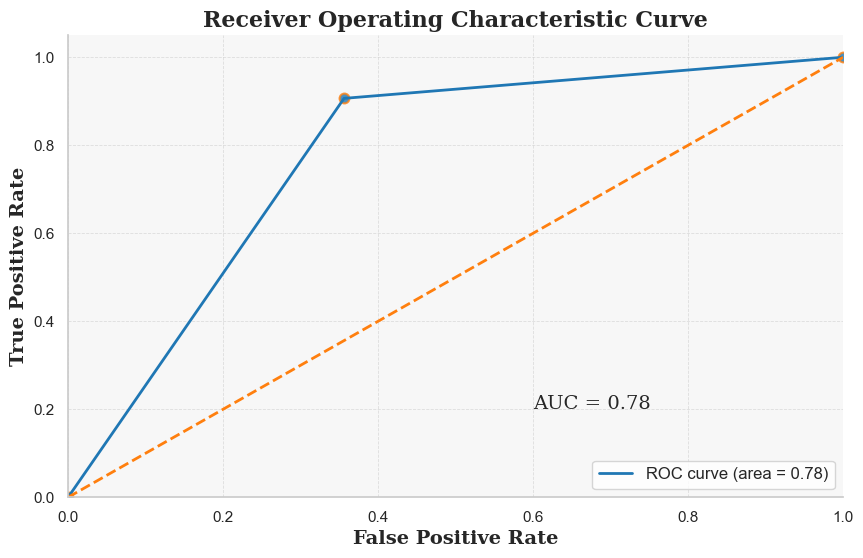

In [5]:
from sklearn.naive_bayes import GaussianNB

seed = 17
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.1, random_state=seed)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

nb = GaussianNB()

model_nb = nb.fit(X_train, Y_train)

pred_nb = model_nb.predict(X_test)

cm_nb = confusion_matrix(Y_test, pred_nb)
print("Confusion Matrix:")
print(cm_nb)

accuracy_nb = accuracy_score(Y_test, pred_nb)
print("Accuracy:", accuracy_nb)

precision_nb = precision_score(Y_test, pred_nb)
print("Precision:", precision_nb)

recall_nb = recall_score(Y_test, pred_nb)
print("Recall:", recall_nb)

f1_score_nb = f1_score(Y_test, pred_nb)
print("F1-score:", f1_score_nb)

auc_nb = roc_auc_score(Y_test, pred_nb)
print("AUC Score:", auc_nb)

specificity_nb = cm_nb[0, 0] / (cm_nb[0, 0] + cm_nb[0, 1])
print("Specificity (True Negative Rate):", specificity_nb)

fpr_nb, tpr_nb, _ = roc_curve(Y_test, pred_nb)

sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))

plt.plot(fpr_nb, tpr_nb, color='#1f77b4', lw=2, label='ROC curve (area = %0.2f)' % auc_nb)
plt.plot([0, 1], [0, 1], color='#ff7f0e', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14, fontweight='bold', family='serif')
plt.ylabel('True Positive Rate', fontsize=14, fontweight='bold', family='serif')
plt.title('Receiver Operating Characteristic Curve', fontsize=16, fontweight='bold', family='serif')
plt.legend(loc="lower right", fontsize=12)

plt.gca().set_facecolor('#f7f7f7')
plt.grid(True, linestyle='--', linewidth=0.6, alpha=0.6)
sns.despine()

plt.annotate(f"AUC = {auc_nb:.2f}", xy=(0.6, 0.2), fontsize=14, family='serif')

plt.scatter(fpr_nb, tpr_nb, color='#1f77b4', edgecolor='#ff7f0e', linewidth=1.5, alpha=0.8, s=50)

plt.show()

Confusion Matrix:
[[172  16]
 [ 21 196]]
Accuracy: 0.908641975308642
Precision: 0.9245283018867925
Recall: 0.9032258064516129
F1-score: 0.9137529137529138
AUC Score: 0.9090597117364447
Specificity (True Negative Rate): 0.9148936170212766


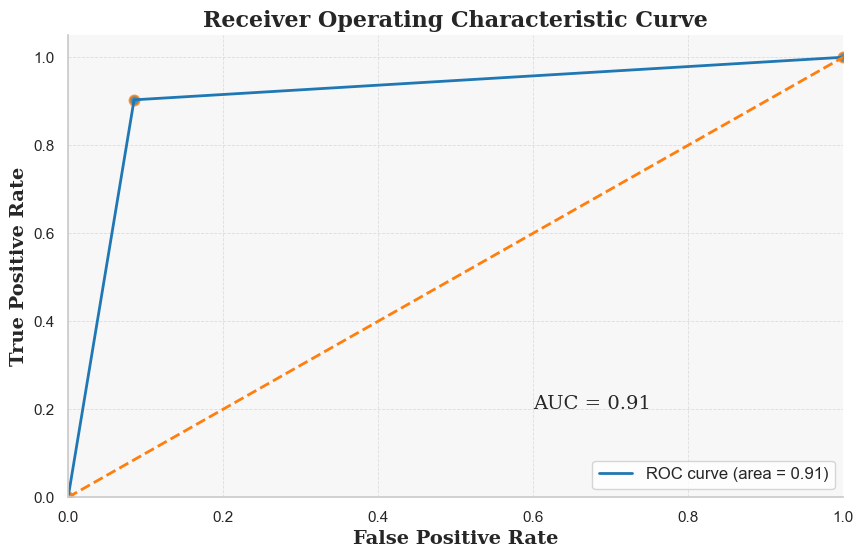

In [6]:
from sklearn.tree import DecisionTreeClassifier

seed=4994
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.1, random_state=seed)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

dtc = DecisionTreeClassifier(random_state=seed)

model_dtc = dtc.fit(X_train, Y_train)

pred_dtc = model_dtc.predict(X_test)

cm_dtc = confusion_matrix(Y_test, pred_dtc)
print("Confusion Matrix:")
print(cm_dtc)

accuracy_dtc = accuracy_score(Y_test, pred_dtc)
print("Accuracy:", accuracy_dtc)

precision_dtc = precision_score(Y_test, pred_dtc)
print("Precision:", precision_dtc)

recall_dtc = recall_score(Y_test, pred_dtc)
print("Recall:", recall_dtc)

f1_score_dtc = f1_score(Y_test, pred_dtc)
print("F1-score:", f1_score_dtc)

auc_dtc = roc_auc_score(Y_test, pred_dtc)
print("AUC Score:", auc_dtc)

specificity_dtc = cm_dtc[0, 0] / (cm_dtc[0, 0] + cm_dtc[0, 1])
print("Specificity (True Negative Rate):", specificity_dtc)

fpr_dtc, tpr_dtc, _ = roc_curve(Y_test, pred_dtc)

sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))

plt.plot(fpr_dtc, tpr_dtc, color='#1f77b4', lw=2, label='ROC curve (area = %0.2f)' % auc_dtc)
plt.plot([0, 1], [0, 1], color='#ff7f0e', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14, fontweight='bold', family='serif')
plt.ylabel('True Positive Rate', fontsize=14, fontweight='bold', family='serif')
plt.title('Receiver Operating Characteristic Curve', fontsize=16, fontweight='bold', family='serif')
plt.legend(loc="lower right", fontsize=12)

plt.gca().set_facecolor('#f7f7f7')
plt.grid(True, linestyle='--', linewidth=0.6, alpha=0.6)
sns.despine()

plt.annotate(f"AUC = {auc_dtc:.2f}", xy=(0.6, 0.2), fontsize=14, family='serif')

plt.scatter(fpr_dtc, tpr_dtc, color='#1f77b4', edgecolor='#ff7f0e', linewidth=1.5, alpha=0.8, s=50)

plt.show()

C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Confusion Matrix:
[[184   6]
 [ 10 205]]
Accuracy: 0.9604938271604938
Precision: 0.9715639810426541
Recall: 0.9534883720930233
F1-score: 0.9624413145539906
AUC Score: 0.960954712362301
Specificity (True Negative Rate): 0.968421052631579


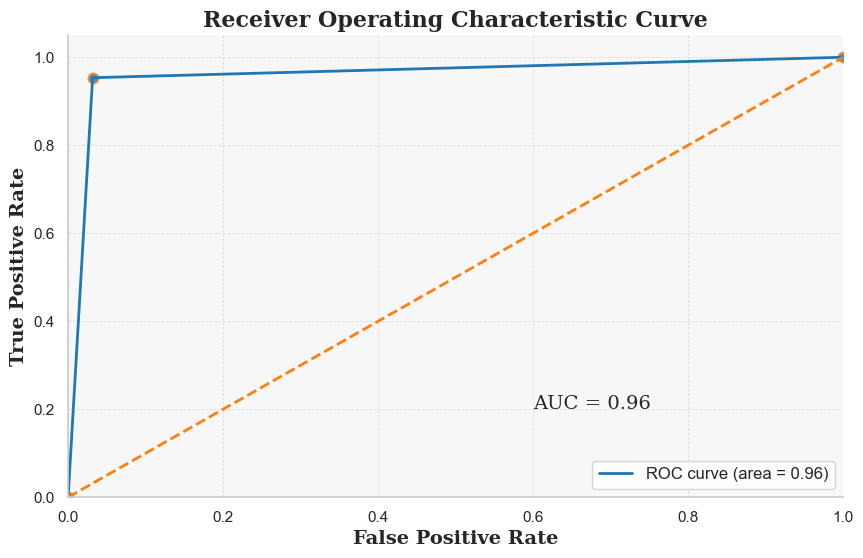

In [7]:
from sklearn.ensemble import RandomForestClassifier

seed=1311
rf = RandomForestClassifier(random_state=seed)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.1, random_state=seed)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

model_rf = rf.fit(X_train, Y_train)

pred_rf = model_rf.predict(X_test)

cm_rf = confusion_matrix(Y_test, pred_rf)
print("Confusion Matrix:")
print(cm_rf)

accuracy_rf = accuracy_score(Y_test, pred_rf)
print("Accuracy:", accuracy_rf)

precision_rf = precision_score(Y_test, pred_rf)
print("Precision:", precision_rf)

recall_rf = recall_score(Y_test, pred_rf)
print("Recall:", recall_rf)

f1_score_rf = f1_score(Y_test, pred_rf)
print("F1-score:", f1_score_rf)

auc_rf = roc_auc_score(Y_test, pred_rf)
print("AUC Score:", auc_rf)

specificity_rf = cm_rf[0, 0] / (cm_rf[0, 0] + cm_rf[0, 1])
print("Specificity (True Negative Rate):", specificity_rf)

fpr_rf, tpr_rf, _ = roc_curve(Y_test, pred_rf)

sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))

plt.plot(fpr_rf, tpr_rf, color='#1f77b4', lw=2, label='ROC curve (area = %0.2f)' % auc_rf)
plt.plot([0, 1], [0, 1], color='#ff7f0e', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14, fontweight='bold', family='serif')
plt.ylabel('True Positive Rate', fontsize=14, fontweight='bold', family='serif')
plt.title('Receiver Operating Characteristic Curve', fontsize=16, fontweight='bold', family='serif')
plt.legend(loc="lower right", fontsize=12)

plt.gca().set_facecolor('#f7f7f7')
plt.grid(True, linestyle='--', linewidth=0.6, alpha=0.6)
sns.despine()

plt.annotate(f"AUC = {auc_rf:.2f}", xy=(0.6, 0.2), fontsize=14, family='serif')

plt.scatter(fpr_rf, tpr_rf, color='#1f77b4', edgecolor='#ff7f0e', linewidth=1.5, alpha=0.8, s=50)

plt.show()

C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\sklearn\neighbors\_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Confusion Matrix:
[[143  40]
 [ 39 183]]
Accuracy: 0.8049382716049382
Precision: 0.820627802690583
Recall: 0.8243243243243243
F1-score: 0.8224719101123595
AUC Score: 0.8028725446758234
Specificity (True Negative Rate): 0.7814207650273224


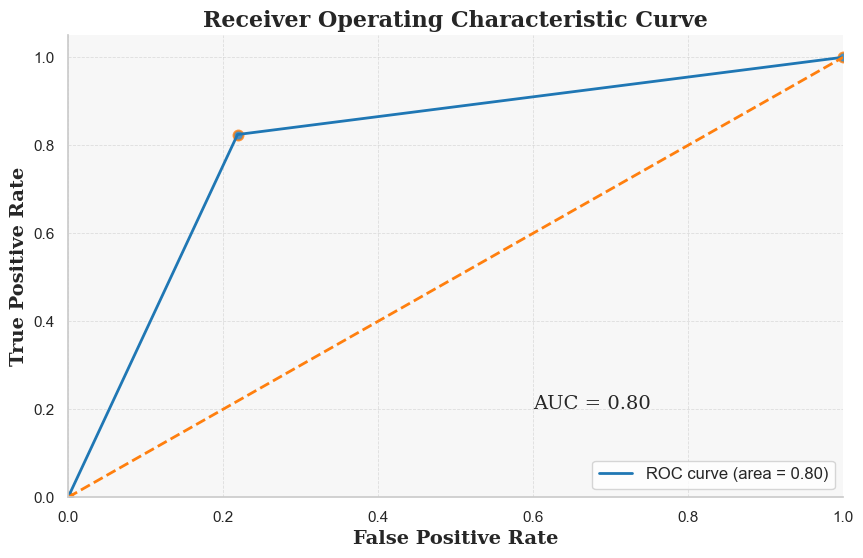

In [8]:
from sklearn.neighbors import KNeighborsClassifier

seed = 1375
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.1, random_state=seed)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

knn = KNeighborsClassifier()

model_knn = knn.fit(X_train, Y_train)

pred_knn = model_knn.predict(X_test)

cm_knn = confusion_matrix(Y_test, pred_knn)
print("Confusion Matrix:")
print(cm_knn)

accuracy_knn = accuracy_score(Y_test, pred_knn)
print("Accuracy:", accuracy_knn)

precision_knn = precision_score(Y_test, pred_knn)
print("Precision:", precision_knn)

recall_knn = recall_score(Y_test, pred_knn)
print("Recall:", recall_knn)

f1_score_knn = f1_score(Y_test, pred_knn)
print("F1-score:", f1_score_knn)

auc_knn = roc_auc_score(Y_test, pred_knn)
print("AUC Score:", auc_knn)

specificity_knn = cm_knn[0, 0] / (cm_knn[0, 0] + cm_knn[0, 1])
print("Specificity (True Negative Rate):", specificity_knn)

fpr_knn, tpr_knn, _ = roc_curve(Y_test, pred_knn)

sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))

plt.plot(fpr_knn, tpr_knn, color='#1f77b4', lw=2, label='ROC curve (area = %0.2f)' % auc_knn)
plt.plot([0, 1], [0, 1], color='#ff7f0e', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14, fontweight='bold', family='serif')
plt.ylabel('True Positive Rate', fontsize=14, fontweight='bold', family='serif')
plt.title('Receiver Operating Characteristic Curve', fontsize=16, fontweight='bold', family='serif')
plt.legend(loc="lower right", fontsize=12)

plt.gca().set_facecolor('#f7f7f7')
plt.grid(True, linestyle='--', linewidth=0.6, alpha=0.6)
sns.despine()

plt.annotate(f"AUC = {auc_knn:.2f}", xy=(0.6, 0.2), fontsize=14, family='serif')

plt.scatter(fpr_knn, tpr_knn, color='#1f77b4', edgecolor='#ff7f0e', linewidth=1.5, alpha=0.8, s=50)

plt.show()

C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Confusion Matrix:
[[150  36]
 [ 26 193]]
Accuracy: 0.8469135802469135
Precision: 0.8427947598253275
Recall: 0.8812785388127854
F1-score: 0.8616071428571429
AUC Score: 0.8438650758580056
Specificity (True Negative Rate): 0.8064516129032258


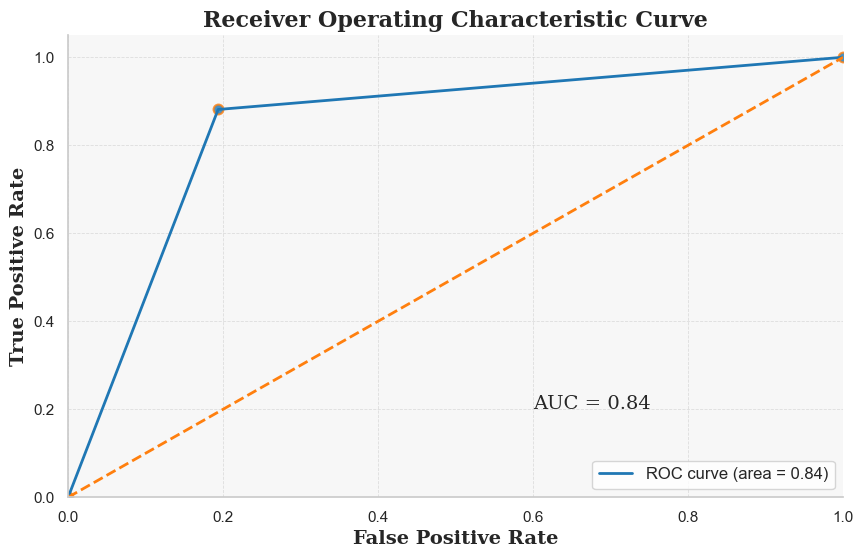

In [9]:
from sklearn.svm import SVC

seed = 3478
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.1, random_state=seed)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

svm = SVC(kernel='rbf', random_state=seed)

model_svm = svm.fit(X_train, Y_train)

pred_svm = model_svm.predict(X_test)

cm_svm = confusion_matrix(Y_test, pred_svm)
print("Confusion Matrix:")
print(cm_svm)

accuracy_svm = accuracy_score(Y_test, pred_svm)
print("Accuracy:", accuracy_svm)

precision_svm = precision_score(Y_test, pred_svm)
print("Precision:", precision_svm)

recall_svm = recall_score(Y_test, pred_svm)
print("Recall:", recall_svm)

f1_score_svm = f1_score(Y_test, pred_svm)
print("F1-score:", f1_score_svm)

auc_svm = roc_auc_score(Y_test, pred_svm)
print("AUC Score:", auc_svm)

specificity_svm = cm_svm[0, 0] / (cm_svm[0, 0] + cm_svm[0, 1])
print("Specificity (True Negative Rate):", specificity_svm)

fpr_svm, tpr_svm, _ = roc_curve(Y_test, pred_svm)

sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))

plt.plot(fpr_svm, tpr_svm, color='#1f77b4', lw=2, label='ROC curve (area = %0.2f)' % auc_svm)
plt.plot([0, 1], [0, 1], color='#ff7f0e', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14, fontweight='bold', family='serif')
plt.ylabel('True Positive Rate', fontsize=14, fontweight='bold', family='serif')
plt.title('Receiver Operating Characteristic Curve', fontsize=16, fontweight='bold', family='serif')
plt.legend(loc="lower right", fontsize=12)

plt.gca().set_facecolor('#f7f7f7')
plt.grid(True, linestyle='--', linewidth=0.6, alpha=0.6)
sns.despine()

plt.annotate(f"AUC = {auc_svm:.2f}", xy=(0.6, 0.2), fontsize=14, family='serif')

plt.scatter(fpr_svm, tpr_svm, color='#1f77b4', edgecolor='#ff7f0e', linewidth=1.5, alpha=0.8, s=50)

plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_19392\2650499412.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Classifier', y='Accuracy', data=df, palette='hls')


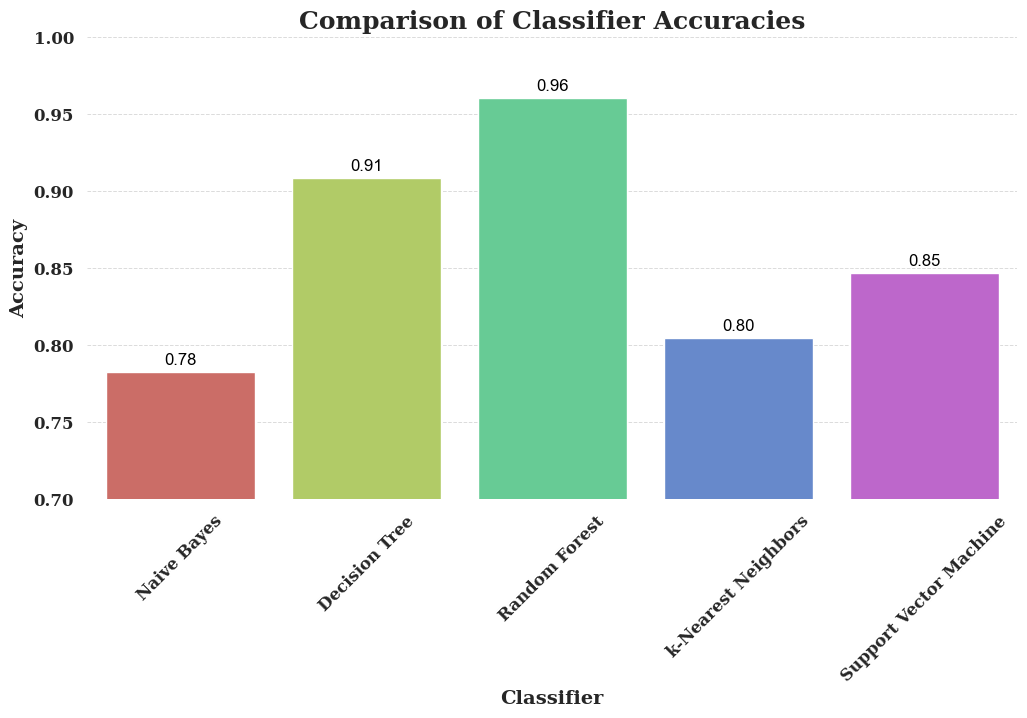

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

data = {
    'Classifier': ['Naive Bayes', 'Decision Tree', 'Random Forest', 'k-Nearest Neighbors', 'Support Vector Machine'],
    'Accuracy': [accuracy_nb, accuracy_dtc, accuracy_rf, accuracy_knn, accuracy_svm]
}

df = pd.DataFrame(data)

plt.figure(figsize=(12, 6))

sns.set(style="whitegrid")
ax = sns.barplot(x='Classifier', y='Accuracy', data=df, palette='hls')

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.title('Comparison of Classifier Accuracies', fontsize=18, fontweight='bold', family='serif')
plt.xlabel('Classifier', fontsize=14, fontweight='bold', family='serif')
plt.ylabel('Accuracy', fontsize=14, fontweight='bold', family='serif')
plt.ylim([0.7, 1])

plt.xticks(fontsize=12, fontweight='bold', family='serif', rotation=45)
plt.yticks(fontsize=12, fontweight='bold', family='serif')

plt.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.7)

sns.despine(left=True, bottom=True)

plt.show()

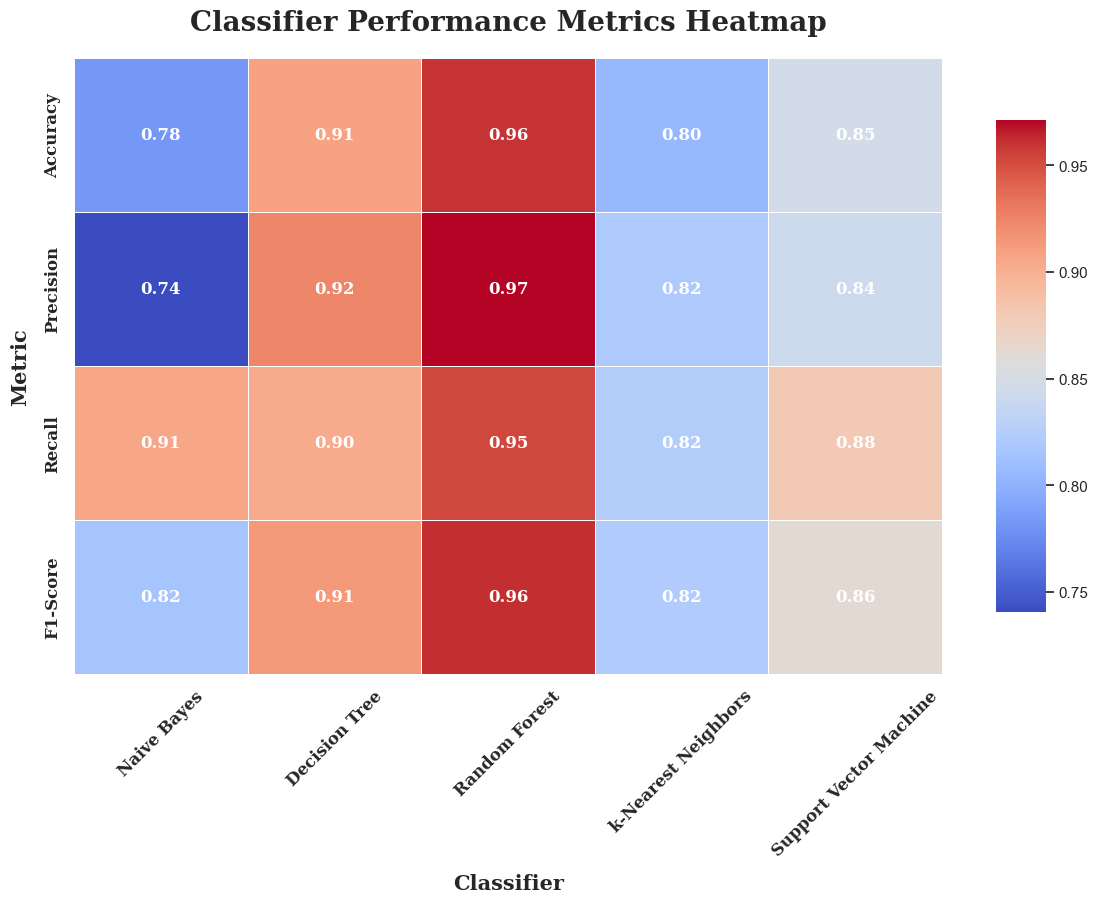

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Naive Bayes': [accuracy_nb, precision_nb, recall_nb, f1_score_nb],
    'Decision Tree': [accuracy_dtc, precision_dtc, recall_dtc, f1_score_dtc],
    'Random Forest': [accuracy_rf, precision_rf, recall_rf, f1_score_rf],
    'k-Nearest Neighbors': [accuracy_knn, precision_knn, recall_knn, f1_score_knn],
    'Support Vector Machine': [accuracy_svm, precision_svm, recall_svm, f1_score_svm]
}

df = pd.DataFrame(data)

df.set_index('Metric', inplace=True)

plt.figure(figsize=(14, 8))
sns.set(style="whitegrid")

ax = sns.heatmap(df, annot=True, cmap='coolwarm', linewidths=.5, fmt=".2f",
                 annot_kws={"size": 12, "weight": "bold", "color": "white", "family": "serif"},
                 cbar_kws={"shrink": .8, "aspect": 10, "ticks": [0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1]})

plt.title('Classifier Performance Metrics Heatmap', fontsize=20, fontweight='bold', family='serif', pad=20)
plt.xlabel('Classifier', fontsize=15, fontweight='bold', family='serif', labelpad=10)
plt.ylabel('Metric', fontsize=15, fontweight='bold', family='serif', labelpad=10)

plt.xticks(fontsize=12, fontweight='bold', family='serif', rotation=45)
plt.yticks(fontsize=12, fontweight='bold', family='serif')

sns.despine(left=True, bottom=True)

plt.show()